In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt

In [3]:
data_path = "data/titan_v2_1024_results_c7g_all_allsamples.csv"
data_df = pd.read_csv(data_path)
data_df

,Unnamed: 0,query,target_id,hit_ids,latency,top1_score,top2_score,recall@1,recall@3,recall@5
0,0,What is the update on my leave request?,f4d26d04-245e-4f99-a4db-9a405dd2f2a3,"['f4d26d04-245e-4f99-a4db-9a405dd2f2a3', '7d75...",3.490186,0.646888,0.467485,1,1,1
1,1,leave application status,f4d26d04-245e-4f99-a4db-9a405dd2f2a3,"['f4d26d04-245e-4f99-a4db-9a405dd2f2a3', '7d75...",0.933152,0.574958,0.463088,1,1,1
2,2,Whats the process for requesting a absence?,f4d26d04-245e-4f99-a4db-9a405dd2f2a3,"['7d759ae6-7d79-48e2-a085-8892d11696fc', '50b4...",0.438815,0.543998,0.470595,0,0,0
3,3,What's the status of my leave application? Wha...,f4d26d04-245e-4f99-a4db-9a405dd2f2a3,"['f4d26d04-245e-4f99-a4db-9a405dd2f2a3', '7d75...",1.015680,0.697186,0.591648,1,1,1
4,4,May I kindly inquire about the current status ...,f4d26d04-245e-4f99-a4db-9a405dd2f2a3,"['f4d26d04-245e-4f99-a4db-9a405dd2f2a3', '7d75...",0.617621,0.792751,0.487280,1,1,1
...,...,...,...,...,...,...,...,...,...,...
1836,1836,May I inquire about the details of our company...,8f362b8e-03bd-40ec-8c06-8f7a651e9851,"['8f362b8e-03bd-40ec-8c06-8f7a651e9851', 'f900...",0.421679,0.670453,0.514828,1,1,1
1837,1837,Vacation policy?,8f362b8e-03bd-40ec-8c06-8f7a651e9851,"['8f362b8e-03bd-40ec-8c06-8f7a651e9851', 'f900...",0.922874,0.624020,0.490869,1,1,1
1838,1838,What are the rules of the road for time off?,8f362b8e-03bd-40ec-8c06-8f7a651e9851,"['60d9b4d6-3e16-44b1-92e4-f51ca229d6f7', 'b7c8...",0.616649,0.513080,0.490009,0,1,1
1839,1839,"What's the deal with time off, man?",8f362b8e-03bd-40ec-8c06-8f7a651e9851,"['b7c898be-81d7-4ae5-9442-e83b4b989da1', '60d9...",0.943269,0.490003,0.487358,0,0,1


In [9]:
true_top1 = data_df[data_df['recall@1']==1]['top1_score']
false_top1 = data_df[data_df['recall@1']==0]['top1_score']

true_top2 = data_df[data_df['recall@1']==1]['top2_score']
false_top2 = data_df[data_df['recall@1']==0]['top2_score']

1.4034004
125
4


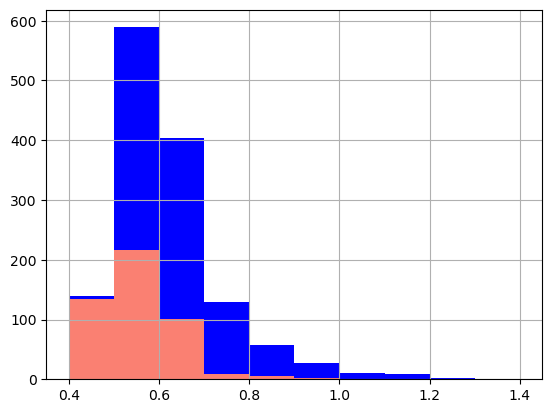

In [35]:
true_top1.hist(color='blue', bins=[0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4])
false_top1.hist(color='salmon', bins=[0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4])
print( np.max(false_top1))
print( np.argmax(false_top1))
print( np.sum( false_top1 > 0.9 ) )

In [10]:
true_diff = true_top1 - true_top2
false_diff = false_top1 - false_top2

0.48148225
2


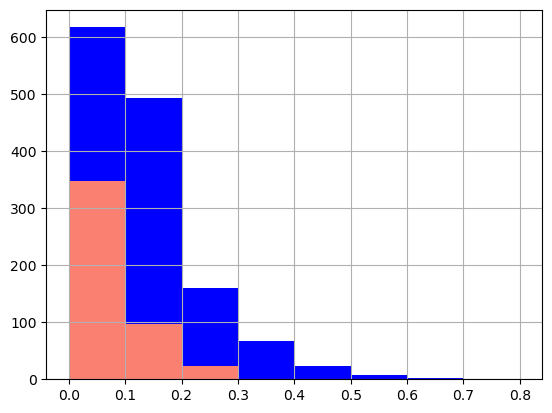

In [36]:
true_diff.hist(color='blue', bins=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
false_diff.hist(color='salmon', bins=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
print( np.max(false_diff))
print( np.sum( false_diff > 0.3 ))

In [18]:
data_df.iloc[125]

Unnamed: 0                                                  125
query              Could you provide an update on my PTO usage?
target_id                  43cbeeac-8849-4bc6-882e-b3029fb23438
hit_ids       ['43cbeeac-8849-4bc6-882e-b3029fb23438', '96cb...
latency                                                0.550282
top1_score                                             0.609054
top2_score                                             0.535582
recall@1                                                      1
recall@3                                                      1
recall@5                                                      1
Name: 125, dtype: object

In [37]:
filtered = data_df[(data_df['top1_score']>0.9) & ((data_df['top1_score']-data_df['top2_score'])>0.3)]

In [38]:
print(len(filtered))

47


In [39]:
print( len(data_df))

1841
